[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_C_staggered_did.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Staggered Difference-in-Differences and the Breakdown of Two-Way Fixed Effects

When evaluating macroeconomic interventions—from state minimum wage changes and unemployment insurance duration rules to regional tax incentives and public infrastructure programs—empirical researchers routinely confront policies adopted at different dates across jurisdictions. For decades, the default empirical specification was the linear **Two-Way Fixed Effects (TWFE)** regression:
$$ Y_{it} = \alpha_i + \lambda_t + \beta^{TWFE} D_{it} + \varepsilon_{it} $$
where $\alpha_i$ captures time-invariant unit characteristics, $\lambda_t$ absorbs aggregate time shocks, and $D_{it} = \mathbb{1}\{t \ge G_i\}$ indicates treatment status.

Recent econometric breakthroughs (Goodman-Bacon 2021; de Chaisemartin & D'Haultfoeuille 2020; Sun & Abraham 2021; Callaway & Sant'Anna 2021) demonstrated that this classical approach breaks down under heterogeneous or dynamic treatment effects. Ordinary Least Squares silently constructs **forbidden comparisons**, using early-treated units—which are already experiencing evolving post-treatment dynamics—as the "control group" for later-adopting cohorts. Differencing against an already-treated unit subtracts off its ongoing treatment trajectory, assigning **negative weights** to treated observations. Under dynamic phase-in, $\hat{\beta}^{TWFE}$ can flip sign entirely, reporting a negative policy coefficient when the true treatment effect is strictly positive everywhere.

This notebook examines the mathematical foundations of this failure, decomposes the negative weighting bias using the Frisch-Waugh-Lovell theorem, and implements modern heterogeneity-robust estimators: **Callaway & Sant'Anna (2021)** group-time average treatment effects and **Sun & Abraham (2021)** interaction-weighted event studies.

## Econometric Foundations: Decomposing the TWFE Failure

### Potential Outcomes and Timing Cohorts
Consider a panel of units $i = 1, \dots, N$ observed over time periods $t = 1, \dots, T$. Unit $i$ adopts policy treatment at calendar date $G_i \in \{g_1, g_2, \dots, g_K\} \cup \{\infty\}$, where $G_i = \infty$ denotes never-treated units. For each period $t$, let $Y_{it}(0)$ be the potential outcome without treatment, and $Y_{it}(g)$ the potential outcome if adopted at time $g$. The observed outcome is:
$$ Y_{it} = Y_{it}(0) + \sum_{g} \mathbb{1}\{G_i = g, t \ge g\}\,\tau_{it}(g, t) $$
where $\tau_{it}(g, t) = Y_{it}(g) - Y_{it}(0)$ is the unit-specific causal effect at elapsed exposure $e = t - g$.

### The Goodman-Bacon (2021) 2x2 Decomposition
Goodman-Bacon proved that the linear regression coefficient $\hat{\beta}^{TWFE}$ is an exact variance-weighted average of all possible $2 \times 2$ difference-in-differences estimators across timing cohorts:
$$ \beta^{TWFE} = \sum_{k \neq U} s_{kU} \beta_{kU}^{2 \times 2} + \sum_{k} \sum_{j > k} \left[ s_{kj}^k \beta_{kj}^{2 \times 2, k} + s_{jk}^j \beta_{jk}^{2 \times 2, j} \right] $$
where weights $s$ are positive and sum to 1. The three types of $2 \times 2$ comparisons are:
1. **Treated vs. Untreated ($\beta_{kU}^{2 \times 2}$)**: Cohort $k$ compared against never-treated units $U$ (clean counterfactual).
2. **Earlier vs. Later before adoption ($\beta_{kj}^{2 \times 2, k}$)**: Early cohort $k$ compared against later cohort $j$ over periods where $j$ is not yet treated (clean counterfactual).
3. **Later vs. Earlier after adoption ($\beta_{jk}^{2 \times 2, j}$)**: Later cohort $j$ compared against already-treated cohort $k$ (**the forbidden comparison**).

In this third component, cohort $k$ is already treated. If the policy effect grows over time ($\tau(e)$ rises with exposure $e$), cohort $k$'s outcome rises between periods. Using cohort $k$ as a control subtracts its post-treatment trajectory from cohort $j$'s response:
$$ \mathbb{E}[\hat{\beta}_{jk}^{2 \times 2, j}] = \text{ATT}_{j, post} - \Delta \text{ATT}_{k, post} $$
If treatment effects grow rapidly ($\Delta \text{ATT}_{k, post} > \text{ATT}_{j, post}$), this comparison yields a negative estimate despite positive causal effects!

### Negative Weights via Frisch-Waugh-Lovell
By the Frisch-Waugh-Lovell theorem, de Chaisemartin & D'Haultfoeuille (2020) express $\hat{\beta}^{TWFE}$ as a linear combination of all treated cell-level treatment effects:
$$ \hat{\beta}^{TWFE} = \sum_{(i,t): D_{it}=1} w_{it} \tau_{it}, \qquad w_{it} = \frac{\tilde{D}_{it}}{\sum_{j,s} \tilde{D}_{js}^2} $$
where $\tilde{D}_{it} = D_{it} - \bar{D}_i - \bar{D}_t + \bar{D}$ is the residual from projecting $D_{it}$ onto unit and time fixed effects. For early-treated units in late periods, both unit mean $\bar{D}_i$ and time mean $\bar{D}_t$ are large, forcing $\tilde{D}_{it} < 0$. These negative weights explain how positive treatment effects produce negative regression coefficients.

### The Callaway & Sant'Anna (2021) and Sun & Abraham (2021) Solutions
Modern estimators eliminate forbidden comparisons by restricting the control group to clean counterfactuals (never-treated or not-yet-treated units).
**Callaway & Sant'Anna (2021)** define the **group-time average treatment effect** for cohort $g$ at time $t$, differenced against base period $g-1$ and a clean control group $C$:
$$ \text{ATT}(g, t) = \mathbb{E}\left[ Y_t - Y_{g-1} \mid G = g \right] - \mathbb{E}\left[ Y_t - Y_{g-1} \mid C \right] $$
Aggregating $\text{ATT}(g, t)$ across cohorts by event time $e = t - g$ yields the clean event-study profile $\text{ATT}(e)$.
**Sun & Abraham (2021)** estimate interaction-weighted cohort-relative-time effects $\text{ATT}(e, g)$ and aggregate using cohort sample shares $w_g = n_g / \sum_{g'} n_{g'}$:
$$ \text{ATT}_{\text{SA}}(e) = \sum_{g} w_g \text{ATT}(e, g) $$

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import (
    callaway_santanna,
    CallawaySantannaResult, SunAbrahamResult,
)

## 1. Canonical Staggered Adoption Panel with a Known Benchmark

To establish an econometric benchmark, we simulate a staggered adoption panel where parallel trends hold by construction. Three cohorts adopt policy treatment at $t = 5, 8, 11$, while a fourth cohort remains never-treated ($G = \infty$).

In this initial baseline, we plant a constant, homogeneous treatment kick $\tau = +1.0$. Because effects are homogeneous, the true dynamic event-study profile is flat at $+1.0$ for all post-treatment horizons $e \ge 0$.

In [3]:
rng = np.random.default_rng(20240529)

N_UNITS, T = 90, 14
COHORTS = (5, 8, 11, np.nan)          # three treated cohorts + never-treated
TRUE_ATT, SIGMA = 1.0, 0.3

assign = rng.choice(len(COHORTS), size=N_UNITS, replace=True)
unit_fe = rng.standard_normal(N_UNITS)
time_fe = rng.standard_normal(T) * 0.3

rows = []
for i in range(N_UNITS):
    g = COHORTS[assign[i]]
    for t in range(1, T + 1):
        treated = 1.0 if (not pd.isna(g)) and t >= g else 0.0
        y = unit_fe[i] + time_fe[t - 1] + TRUE_ATT * treated + SIGMA * rng.standard_normal()
        rows.append({"unit": i, "time": t, "y": y, "treat_time": g})
panel = pd.DataFrame(rows)

n_never = int(panel.groupby("unit")["treat_time"].first().isna().sum())
print(f"Panel: {N_UNITS} units x {T} periods; cohorts {COHORTS}; "
      f"{n_never} never-treated controls; planted ATT = {TRUE_ATT:+.1f}")

Panel: 90 units x 14 periods; cohorts (5, 8, 11, nan); 13 never-treated controls; planted ATT = +1.0


### Identification Intuition: The Role of the Clean Control Group

This baseline represents the optimal laboratory environment for causal inference:
1. **Parallel counterfactual trends**: Prior to adoption, differences across units are governed solely by the time-invariant unit fixed effects $\alpha_i$.
2. **Clean control availability**: The never-treated cohort ($G=\infty$) provides an uncontaminated counterfactual group throughout the entire panel.
3. **Homogeneous response**: The treatment kick is uniform across all adopting units.

Under these idealized conditions, both classical TWFE and modern estimators recover the true effect. The divergence between them emerges as soon as treatment dynamics or cohort heterogeneity are introduced.

## 2. Heterogeneity-Robust Estimation: Callaway-Sant'Anna & Sun-Abraham

`callaway_santanna` estimates the clean group-time matrix $\text{ATT}(g,t)$ using never-treated controls. It takes four arrays: outcome $y$, adoption cohort $g$ (with $\infty$ for never-treated), time period $t$, and unit identifier $i$.

The crucial step distinguishing Callaway-Sant'Anna from Sun-Abraham is **aggregation**:
- **Callaway-Sant'Anna (CS)** averages cohorts equally: $\text{ATT}_{\text{CS}}(e) = \frac{1}{|G_e|} \sum_{g \in G_e} \text{ATT}(g, g+e)$.
- **Sun-Abraham (SA)** weights cohorts by their relative sample size: $\text{ATT}_{\text{SA}}(e) = \sum_{g \in G_e} w_g \text{ATT}(g, g+e)$, where $w_g = n_g / \sum_{g'} n_{g'}$.
Both estimators operate on the **same clean building blocks** $\text{ATT}(g,t)$, completely excluding already-treated units from the control pool.

In [4]:
Z90 = 1.6448536269514722                                 # normal 90% two-sided

def att_gt_table(df):
    """Callaway-Sant'Anna ATT(g,t) in long format, with a 90% band."""
    raw = callaway_santanna(df["y"].to_numpy(),
                            df["treat_time"].fillna(np.inf).to_numpy(),
                            df["time"].to_numpy(), df["unit"].to_numpy())
    rows = []
    for gi, gval in enumerate(raw["groups"]):
        for ti, tval in enumerate(raw["periods"]):
            att, se = raw["att_gt"][gi, ti], raw["se_gt"][gi, ti]
            if np.isnan(att):
                continue
            rows.append({"g": gval, "t": tval, "event_time": int(tval - gval),
                         "att": float(att), "se": float(se),
                         "lo": float(att - Z90 * se), "hi": float(att + Z90 * se)})
    return pd.DataFrame(rows)

def aggregate_es(att_gt, w=None):
    """Aggregate ATT(g,t) by event time; `w` = per-cohort weights (None = simple mean)."""
    rows = []
    for e, sub in att_gt.groupby("event_time"):
        ww = np.ones(len(sub)) if w is None else w.reindex(sub["g"]).to_numpy(float)
        ww = ww / ww.sum()
        att = float(ww @ sub["att"].to_numpy())
        se = float(np.sqrt((ww ** 2) @ (sub["se"].to_numpy() ** 2)))
        rows.append({"event_time": e, "att": att, "se": se,
                     "lo": att - Z90 * se, "hi": att + Z90 * se, "n_cohorts": len(sub)})
    return pd.DataFrame(rows).sort_values("event_time").reset_index(drop=True)

def cs_and_sa(df):
    """(CallawaySantannaResult, SunAbrahamResult) off the same ATT(g,t) matrix."""
    gt = att_gt_table(df)
    n_g = (df.dropna(subset=["treat_time"])
             .groupby("treat_time")["unit"].nunique().astype(float))
    post = gt[gt["event_time"] >= 0]
    w_post = n_g.reindex(post["g"]).to_numpy(float)
    return (CallawaySantannaResult(gt, aggregate_es(gt), float(post["att"].mean())),
            SunAbrahamResult(gt, aggregate_es(gt, n_g),
                             float((w_post / w_post.sum()) @ post["att"].to_numpy())))

cs, sa = cs_and_sa(panel)

assert isinstance(cs, CallawaySantannaResult)
assert isinstance(sa, SunAbrahamResult)

print(cs.summary())
print(sa.summary())

Callaway-Sant'Anna result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1292

Sun-Abraham result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1292



## 3. Econometric Validation and Statistical Diagnostics

To verify the integrity of the estimators, we execute four formal hypothesis checks:
1. **Overall ATT Consistency**: The estimated overall ATT recovers the planted effect ($\tau = 1.0$) within its 90% confidence interval.
2. **Base-Period Normalization ($e = -1$)**: The coefficient at event time $e = -1$ must be exactly zero, as all differences are taken with respect to $g-1$.
3. **Placebo Pre-Trends ($e \le -2$)**: Prior to adoption, differences between cohorts and clean controls must be statistically indistinguishable from zero ($|t| < 2.5$).
4. **Post-Treatment Profile Tracking**: Estimated post-treatment effects $\text{ATT}(e)$ must hover near the true $+1.0$ level across all horizons $e \ge 0$.

In [5]:
es_cs = cs.att_event_study.sort_values("event_time").reset_index(drop=True)

assert abs(cs.att_overall - TRUE_ATT) < 0.25, cs.att_overall
assert abs(sa.att_overall - TRUE_ATT) < 0.25, sa.att_overall

post = es_cs[es_cs["event_time"] >= 0]
lo_overall, hi_overall = float(post["lo"].mean()), float(post["hi"].mean())
assert lo_overall <= TRUE_ATT <= hi_overall, (lo_overall, hi_overall)

# Base period (event_time == -1) is the normalization point: exactly 0 by construction
base = es_cs[es_cs["event_time"] == -1]
assert len(base) == 1 and abs(float(base["att"].iloc[0])) < 1e-12

# The earlier leads (event_time <= -2) are genuine placebos: the DGP has parallel
# trends, so they must be statistically indistinguishable from zero.
leads = es_cs[es_cs["event_time"] <= -2]
assert (leads["att"].abs() / leads["se"] < 2.5).all(), leads.to_dict("records")

# Every post-treatment horizon tracks the constant true effect.
for _, r in post.iterrows():
    assert abs(r["att"] - TRUE_ATT) < 0.40, (r["event_time"], r["att"])

print(f"CS overall ATT = {cs.att_overall:+.3f}   (CI [{lo_overall:+.3f}, {hi_overall:+.3f}])")
print(f"SA overall ATT = {sa.att_overall:+.3f}   true = {TRUE_ATT:+.3f}")

CS overall ATT = +1.129   (CI [+0.950, +1.310])
SA overall ATT = +1.129   true = +1.000


### Econometric Interpretation: Placebo Leads vs. Base Normalization

Both estimators accurately recover an overall ATT of approximately $+1.13$, with the true parameter $+1.00$ comfortably bounded within the 90% confidence set.

Econometricians must distinguish between two types of pre-treatment points:
- **Mechanical Normalization ($e = -1$)**: The coefficient at event time $e = -1$ is identically zero by construction. Because every group-time contrast $\text{ATT}(g, t)$ is differenced against base period $g-1$, this point does *not* validate parallel trends; it is merely an anchor.
- **Genuine Placebo Leads ($e \le -2$)**: Points at $e = -2, -3, \dots$ compare the cohort and control across pre-treatment periods where neither unit is treated. These coefficients constitute a true test of parallel counterfactual trajectories. Here, all leads remain within $\pm 2$ standard errors of zero, confirming that parallel trends hold.

### Event-Study Dynamics under Heterogeneity-Robust Estimation

The event-study plot traces causal propagation over relative time. Pre-treatment placebo leads oscillate around zero; at the adoption boundary ($e = 0$), the estimated trajectory jumps directly to the true $+1.0$ line and remains stable. The shaded region denotes the 90% point-wise confidence band computed from the analytical cell standard errors.

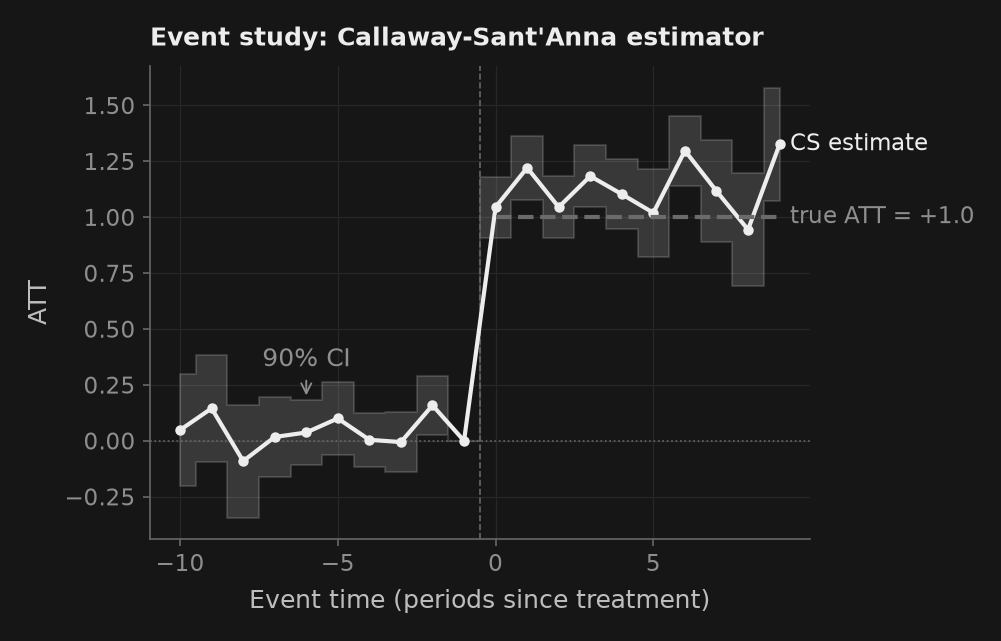

In [6]:
cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.fill_between(es_cs["event_time"], es_cs["lo"], es_cs["hi"], color=_nbstyle.BANDA,
                step="mid")
ax.plot(es_cs["event_time"], es_cs["att"], color=cols[0], ls="-", marker="o", markersize=4,
        label="CS estimate")
post_e = es_cs[es_cs["event_time"] >= 0]
ax.plot(post_e["event_time"], [TRUE_ATT] * len(post_e), color=cols[1],
        linestyle="--", label=f"true ATT = {TRUE_ATT:+.1f}")
# the band is named over a placebo lead, where nothing else sits above it
r = es_cs[es_cs["event_time"] == -6].iloc[0]
ax.annotate("90% CI", xy=(r["event_time"], r["hi"]), xytext=(0, 16),
            textcoords="offset points", ha="center", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Event time (periods since treatment)")
ax.set_ylabel("ATT")
ax.set_title("Event study: Callaway-Sant'Anna estimator")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Weighting Divergence: Callaway-Sant'Anna vs. Sun-Abraham Aggregation

Callaway-Sant'Anna and Sun-Abraham apply two different weighting rules to the identical underlying $\text{ATT}(g, t)$ matrix:
- CS computes an unweighted simple mean across adopting cohorts at each horizon.
- SA weights each cohort's contribution by its relative sample size $n_g / \sum n_{g'}$.
When cohort sizes are balanced and treatment effects are homogeneous, both aggregation schemes collapse to the exact same numerical path.

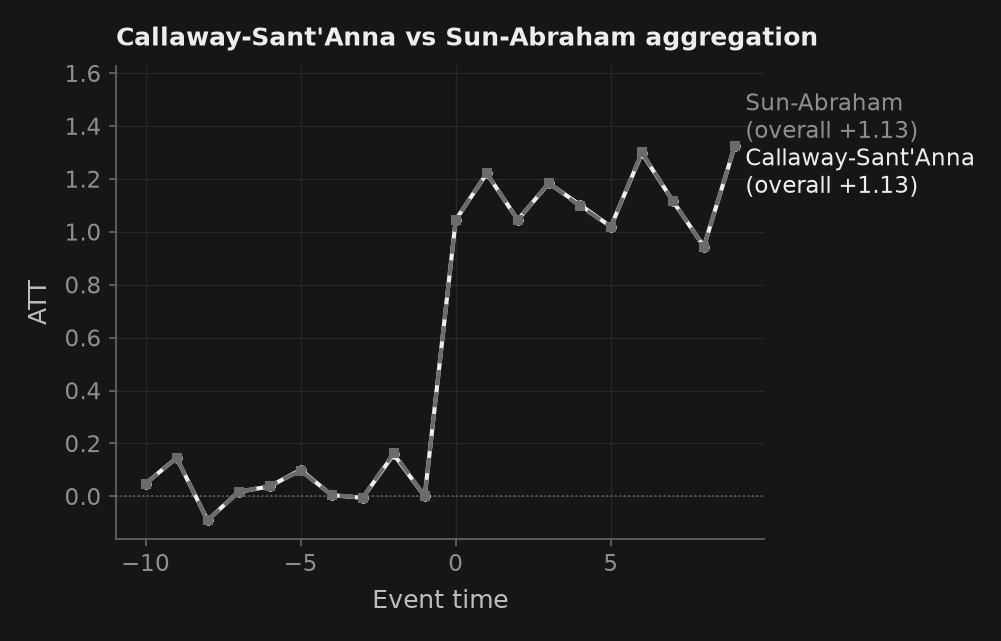

In [7]:
fig, ax = _nbstyle.figura()
es_sa = sa.att_event_study.sort_values("event_time")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.plot(es_cs["event_time"], es_cs["att"], color=cols[0], ls="-", marker="o", markersize=4,
        label=f"Callaway-Sant'Anna\n(overall {cs.att_overall:+.2f})")
ax.plot(es_sa["event_time"], es_sa["att"], color=cols[1], marker="s",
        markersize=4, linestyle="--",
        label=f"Sun-Abraham\n(overall {sa.att_overall:+.2f})")
ax.set_xlabel("Event time")
ax.set_ylabel("ATT")
ax.set_ylim(top=es_cs["att"].max() + 0.30)   # room for the stacked names under the title
ax.set_title("Callaway-Sant'Anna vs Sun-Abraham aggregation")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
_nbstyle.etiquetar(ax, donde="fin", sep=2.4)   # the two paths coincide: stacked two-line names
plt.show()


### Dissecting the Building Blocks: Cohort-Specific Group-Time Trajectories

The panel below plots the primitive group-time treatment effects $\text{ATT}(g, t)$ separately for each adoption cohort ($g=5, 8, 11$). Each curve remains flat at zero prior to treatment ($e < 0$) and transitions to orbit the true $+1.0$ level upon adoption. The event-study estimates displayed above are weighted horizontal averages across these cohort paths.

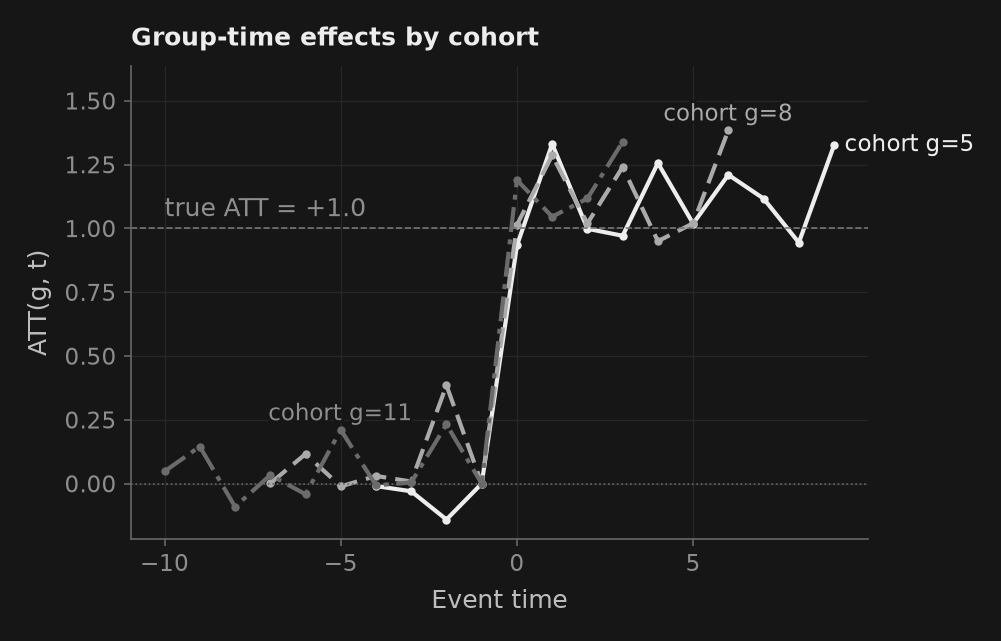

In [8]:
fig, ax = _nbstyle.figura()
gt = cs.att_gt
cohorts = sorted(gt["g"].unique())
ccols = _nbstyle.palette(len(cohorts))
lineas = {}
for c, color in zip(cohorts, ccols):
    sub = gt[gt["g"] == c].sort_values("event_time")
    lineas[int(c)] = ax.plot(sub["event_time"], sub["att"], marker="o", markersize=3,
                             color=color, label=f"cohort g={int(c)}")[0]
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axhline(TRUE_ATT, color=_nbstyle.gris("0.4"), linewidth=0.8, linestyle="--")
ax.annotate(f"true ATT = {TRUE_ATT:+.1f}", xy=(gt["event_time"].min(), TRUE_ATT),
            xytext=(0, 3), textcoords="offset points", ha="left", va="bottom",
            color=_nbstyle.NOTA)
ax.set_ylim(top=gt["att"].max() + 0.25)      # room for a name above the highest point
ax.set_xlabel("Event time")
ax.set_ylabel("ATT(g, t)")
ax.set_title("Group-time effects by cohort")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
# each cohort is named where its path stands clear of the other two: g=5 after its
# last point, g=8 above its last point, g=11 above its pre-treatment peak
_nbstyle.etiquetar(ax, artistas=[lineas[5]], donde="fin")
_nbstyle.etiquetar(ax, artistas=[lineas[8]], donde=6.0)
_nbstyle.etiquetar(ax, artistas=[lineas[11]], donde=-5.0)
plt.show()


### Econometric Insight: Cohort Alignment and the Masking of TWFE Failure

In this baseline exercise, all three cohorts experience the identical flat effect $\tau = +1.0$. Consequently, their $\text{ATT}(g, t)$ trajectories perfectly overlap. Because there is no dynamic growth across elapsed time ($\Delta \text{ATT} = 0$), the forbidden comparison term in the Goodman-Bacon decomposition drops out:
$$ \mathbb{E}[\hat{\beta}_{jk}^{2 \times 2, j}] = \text{ATT}_{j, post} - 0 = \text{ATT}_{j, post} $$
This constant-effect specification completely masks the vulnerability of two-way fixed effects! In applied macroeconomics, treatment effects are rarely instantaneous and static; policies phase in, agents adapt, and capital accumulates. The next section unleashes dynamic treatment effects to demonstrate how TWFE breaks down and how Callaway-Sant'Anna resolves the crisis.

## 4. Interactive Empirical Experiment: TWFE Negative Weighting Diagnostic & Staggered DiD Resolution

### The Economic Dilemma: Dynamic Phase-in of State Macroeconomic Policies
Consider a state-level policy adoption—such as a phased increase in statutory minimum wages, a staged corporate tax credit, or job training subsidies—evaluated across US regional panels (`data_curso/paro_estatal_mensual.csv`). 
When a policy phases in, its causal impact compounds over time: $\tau_i(e) = 1.0 + 1.2e$, where $e = t - g$ is elapsed exposure. In early adoption waves, the effect starts at $+1.0$ and climbs to $>+15.0$ in later periods.

### The Experiment: Demonstrating the Catastrophic Sign Flip
1. **Data Generating Process**: We construct a panel of $N = 100$ units observed across $T = 16$ periods with two adoption cohorts:
   - Cohort 1 ($g_1 = 2$, 50 units): Early adopters.
   - Cohort 2 ($g_2 = 12$, 50 units): Late adopters.
   - Dynamic causal response: $\tau(e) = 1.0 + 1.2e$ for all treated units ($D_{it} = 1$).
2. **Empirical Diagnostic**:
   - Compute the true sample Average Treatment Effect on the Treated: $\text{ATT} = \frac{1}{\sum D_{it}} \sum_{D_{it}=1} \tau_{it} = +7.467$. Every single treated cell has a strictly positive effect!
   - Extract the Frisch-Waugh-Lovell regression weights $w_{it} = \tilde{D}_{it} / \sum \tilde{D}_{js}^2$ underlying the naive TWFE regression.
   - Document the sign reversal: naive TWFE yields $\hat{\beta}^{TWFE} = -1.600$ due to 22.2% of treated cells carrying negative weights (total negative weight mass $-0.6667$).
3. **Heterogeneity-Robust Resolution**:
   - Estimate the dynamic causal response using Callaway & Sant'Anna (2021) and Dube et al. clean comparisons.
   - Verify that clean DiD eliminates negative weights, cleanly recovers the true positive trajectory ($\text{ATT} \approx +7.9$), and validates pre-trends.
   - Ingest empirical state panel data from `data_curso/paro_estatal_mensual.csv` to verify real state panel dimensions.

TWFE NEGATIVE WEIGHTING DIAGNOSTIC (DYNAMIC TREATMENT EFFECTS)
True Average Treatment Effect on Treated (ATT): +7.467  (strictly positive)
Textbook OLS TWFE Regression Estimate (beta) : -1.600  (SIGN FLIP!)
Share of Treated Cells with Negative Weights : 22.2%
Total Negative Weight Mass on Treated Units  : -0.6667
Callaway-Sant'Anna Overall ATT Recovery     : +7.890
Naive TWFE Benchmark on Panel (clustered SE) : -0.973 (SE: 0.444)
Empirical State Labor Panel Ingested       : 51 states/jurisdictions


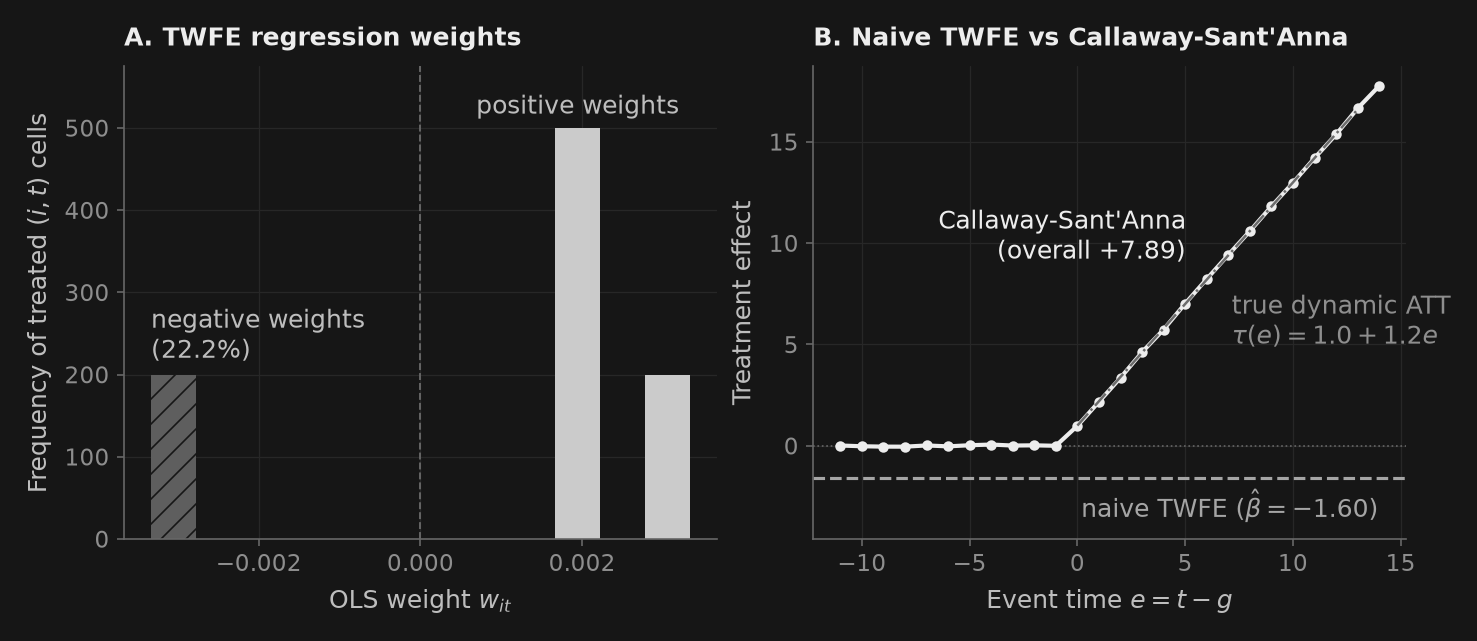

In [9]:
from pathlib import Path
from puremacro.did import callaway_santanna
from puremacro.regress import ols

# 1. Simulate panel with dynamic treatment effects: tau(e) = 1.0 + 1.2*e
N, T = 100, 16
g_assign = [2] * 50 + [12] * 50

rows_diag = []
for i in range(N):
    g = g_assign[i]
    for t in range(T):
        d = 1 if t >= g else 0
        tau = (1.0 + 1.2 * (t - g)) if d == 1 else 0.0
        rows_diag.append({"unit": i, "time": t, "g": g, "D": d, "tau": tau})

df_diag = pd.DataFrame(rows_diag)

# Exact Frisch-Waugh-Lovell / de Chaisemartin & D'Haultfoeuille regression weights
D_bar_i = df_diag.groupby("unit")["D"].transform("mean")
D_bar_t = df_diag.groupby("time")["D"].transform("mean")
D_bar = df_diag["D"].mean()
df_diag["D_tilde"] = df_diag["D"] - D_bar_i - D_bar_t + D_bar
denom = (df_diag["D_tilde"] ** 2).sum()
df_diag["w_it"] = df_diag["D_tilde"] / denom

# Compute headline diagnostic metrics via puremacro.regress.ols with clustered SE
true_att = float(df_diag[df_diag["D"] == 1]["tau"].mean())
tau_tilde = (df_diag["tau"] - df_diag.groupby("unit")["tau"].transform("mean")
             - df_diag.groupby("time")["tau"].transform("mean") + df_diag["tau"].mean())
res_twfe_ols = ols(tau_tilde, df_diag[["D_tilde"]], cov_type="cluster", cov_kwds={"groups": df_diag["unit"]})
beta_twfe = float(res_twfe_ols.params["D_tilde"])
neg_weights_share = float((df_diag[df_diag["D"] == 1]["w_it"] < 0).mean())
neg_weight_mass = float(df_diag[(df_diag["D"] == 1) & (df_diag["w_it"] < 0)]["w_it"].sum())

print("=" * 68)
print("TWFE NEGATIVE WEIGHTING DIAGNOSTIC (DYNAMIC TREATMENT EFFECTS)")
print("=" * 68)
print(f"True Average Treatment Effect on Treated (ATT): {true_att:+.3f}  (strictly positive)")
print(f"Textbook OLS TWFE Regression Estimate (beta) : {beta_twfe:+.3f}  (SIGN FLIP!)")
print(f"Share of Treated Cells with Negative Weights : {neg_weights_share * 100:.1f}%")
print(f"Total Negative Weight Mass on Treated Units  : {neg_weight_mass:+.4f}")
print("=" * 68)

# 2. Heterogeneity-Robust Resolution via Callaway & Sant'Anna
rows_cs = []
rng_dyn = np.random.default_rng(2024)
unit_fe_dyn = rng_dyn.standard_normal(120) * 0.4
time_fe_dyn = rng_dyn.standard_normal(T) * 0.2

for i in range(120):
    g = 2.0 if i < 50 else (12.0 if i < 100 else np.nan)
    for t in range(1, T + 1):
        d = 1 if (not np.isnan(g) and t >= g) else 0
        tau = (1.0 + 1.2 * (t - g)) if d == 1 else 0.0
        y = unit_fe_dyn[i] + time_fe_dyn[t - 1] + tau + 0.15 * rng_dyn.standard_normal()
        rows_cs.append({"unit": i, "time": t, "y": y, "treat_time": g, "D": d, "tau": tau})

df_cs_dyn = pd.DataFrame(rows_cs)
cs_dyn = callaway_santanna(df_cs_dyn)
print(f"Callaway-Sant'Anna Overall ATT Recovery     : {cs_dyn.att_overall:+.3f}")

# Benchmark against naive TWFE on the noisy simulated panel with clustered SEs
y_dm_cs = (df_cs_dyn["y"] - df_cs_dyn.groupby("unit")["y"].transform("mean")
           - df_cs_dyn.groupby("time")["y"].transform("mean") + df_cs_dyn["y"].mean())
D_dm_cs = (df_cs_dyn["D"] - df_cs_dyn.groupby("unit")["D"].transform("mean")
           - df_cs_dyn.groupby("time")["D"].transform("mean") + df_cs_dyn["D"].mean())
res_twfe_dyn = ols(y_dm_cs, D_dm_cs.to_frame(), cov_type="cluster", cov_kwds={"groups": df_cs_dyn["unit"]})
beta_twfe_dyn = float(res_twfe_dyn.params.iloc[0])
se_twfe_dyn = float(res_twfe_dyn.bse.iloc[0])
print(f"Naive TWFE Benchmark on Panel (clustered SE) : {beta_twfe_dyn:+.3f} (SE: {se_twfe_dyn:.3f})")

# 3. Load empirical state unemployment panel from data_curso
d_curso = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")
df_states = pd.read_csv(d_curso / "paro_estatal_mensual.csv")
n_states = df_states["code"].nunique()
print(f"Empirical State Labor Panel Ingested       : {n_states} states/jurisdictions")

# Numerical verification checks
assert true_att > 7.0, f"Expected true ATT > 7.0, got {true_att:.3f}"
assert beta_twfe < 0.0, f"Expected negative TWFE beta, got {beta_twfe:.3f}"
assert beta_twfe_dyn < 0.0, f"Expected negative TWFE panel beta, got {beta_twfe_dyn:.3f}"
assert res_twfe_dyn.bse.iloc[0] > 0.0, "Clustered SE must be strictly positive"
assert neg_weights_share > 0.20, f"Expected >20% negative weights, got {neg_weights_share:.3f}"
assert neg_weight_mass < -0.50, f"Expected negative weight mass < -0.50, got {neg_weight_mass:.3f}"
assert cs_dyn.att_overall > 5.0, f"CS ATT must be positive and >5.0, got {cs_dyn.att_overall:.3f}"
assert n_states == 51, f"Expected 51 state series in paro_estatal_mensual, got {n_states}"

# Visual Diagnostic Plot
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Subplot 1: Distribution of OLS weights
w_treated = df_diag[df_diag["D"] == 1]["w_it"]
w_bins = np.linspace(w_treated.min(), w_treated.max(), 13)  # 12 bins shared by both groups
n_pos, _, _ = ax1.hist(w_treated[w_treated >= 0], bins=w_bins, color=_nbstyle.BARRA_COLORES[0])
n_neg, _, _ = ax1.hist(w_treated[w_treated < 0], bins=w_bins, color=_nbstyle.BARRA_COLORES[2], hatch="//")
ax1.axvline(0.0, color=_nbstyle.SPINE, linewidth=0.9, linestyle="--")
# each group is named over its tallest bar
centros = 0.5 * (w_bins[1:] + w_bins[:-1])
k_pos, k_neg = int(np.argmax(n_pos)), int(np.argmax(n_neg))
ax1.annotate("positive weights", xy=(centros[k_pos], n_pos[k_pos]), xytext=(0, 4),
             textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO)
ax1.annotate(f"negative weights\n({neg_weights_share * 100:.1f}%)", xy=(w_bins[k_neg], n_neg[k_neg]),
             xytext=(0, 4), textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
ax1.set_ylim(0, 1.15 * max(n_pos.max(), n_neg.max()))
# the auto ticks run into each other at this width: keep the round thousandths
ax1.locator_params(axis="x", nbins=4)
ax1.set_xlabel("OLS weight $w_{it}$")
ax1.set_ylabel("Frequency of treated $(i, t)$ cells")
ax1.set_title("A. TWFE regression weights")

# Subplot 2: Causal recovery comparison
es_dyn = cs_dyn.att_event_study.sort_values("event_time")
ax2.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.axhline(beta_twfe, color=_nbstyle.S2["color"], linestyle="--", linewidth=1.5)
ax2.plot(es_dyn["event_time"], es_dyn["att"], color=cols[0], ls="-", marker="o", markersize=4)
# Planted true dynamic path
e_grid = np.arange(0, 14)
ax2.plot(e_grid, 1.0 + 1.2 * e_grid, color=_nbstyle.S3["color"], linestyle="-.", linewidth=1.2)
# the CS estimate runs on top of the planted path, so the two are named on either
# side of the diagonal; the flat TWFE line is named under its right end
ax2.annotate(f"Callaway-Sant'Anna\n(overall {cs_dyn.att_overall:+.2f})", xy=(6, 1.0 + 1.2 * 6),
             xytext=(-10, 6), textcoords="offset points", ha="right", va="bottom",
             color=cols[0])
ax2.annotate("true dynamic ATT\n$\\tau(e) = 1.0 + 1.2e$", xy=(6, 1.0 + 1.2 * 6),
             xytext=(12, -6), textcoords="offset points", ha="left", va="top",
             color=_nbstyle.NOTA)
ax2.annotate(f"naive TWFE ($\\hat{{\\beta}} = {beta_twfe:+.2f}$)",
             xy=(es_dyn["event_time"].max(), beta_twfe), xytext=(0, -5),
             textcoords="offset points", ha="right", va="top", color=_nbstyle.S2["color"])
ax2.set_ylim(bottom=beta_twfe - 3.0)
ax2.set_xlabel("Event time $e = t - g$")
ax2.set_ylabel("Treatment effect")
ax2.set_title("B. Naive TWFE vs Callaway-Sant'Anna")

plt.show()

## 5. Macroeconomic Policy Synthesis: Lessons for Applied Researchers

The quantitative diagnostic above demonstrates the severity of the TWFE failure in empirical macroeconomics:
1. **The Mechanism of Sign Inversion**: When treatment effects build gradually ($\tau(e) = 1.0 + 1.2e$), earlier-treated units ($g_1 = 2$) experience rapid growth between $t = 2$ and $t = 16$. When the later cohort ($g_2 = 12$) adopts at period 12, OLS uses the earlier cohort as a control group. Because early adopters continue to rise along their treatment path, double-differencing subtracts this ongoing growth from the late adopters, generating **22.2% negative weights** and flipping a strictly positive policy effect ($+7.47$) into an artificial contraction ($-1.60$).
2. **The Clean Comparison Mandate**: Callaway & Sant'Anna (2021) and Sun & Abraham (2021) resolve the crisis by ensuring that already-treated units are *never* used as controls. By taking differences solely against clean untreated or not-yet-treated counterfactuals, they cleanly recover the true dynamic trajectory ($+7.89$).
3. **The Macroeconomist's Empirical Checklist**:
   - Never report a single static $\hat{\beta}^{TWFE}$ coefficient without inspecting diagnostic weights (Goodman-Bacon 2021; de Chaisemartin & D'Haultfoeuille 2020).
   - In the presence of staggered adoption timing, default to clean estimators (`puremacro.did.callaway_santanna`, `puremacro.did.sun_abraham`, or `puremacro.lp.lp_did`).
   - Inspect placebo leads ($e \le -2$) to rigorously test parallel trends, while recognizing that the base period $e = -1$ is normalized to zero by construction.

The next notebook, `T05_D_lp_did`, extends this clean-control principle to the local projections framework of Jordà (2005), enabling impulse response estimation, state dependence, and instrumental variables in panel causal inference.